In [1]:
# program for time-Series- forecasting with the LSTM Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [6]:
# create a simple time series dataset
data = [100,105,110,115,120,125,130,128,135,140,145,155,160,158,165,170,175,180,185]
df=pd.DataFrame(data, columns=['value'])
print(df)

    value
0     100
1     105
2     110
3     115
4     120
5     125
6     130
7     128
8     135
9     140
10    145
11    155
12    160
13    158
14    165
15    170
16    175
17    180
18    185


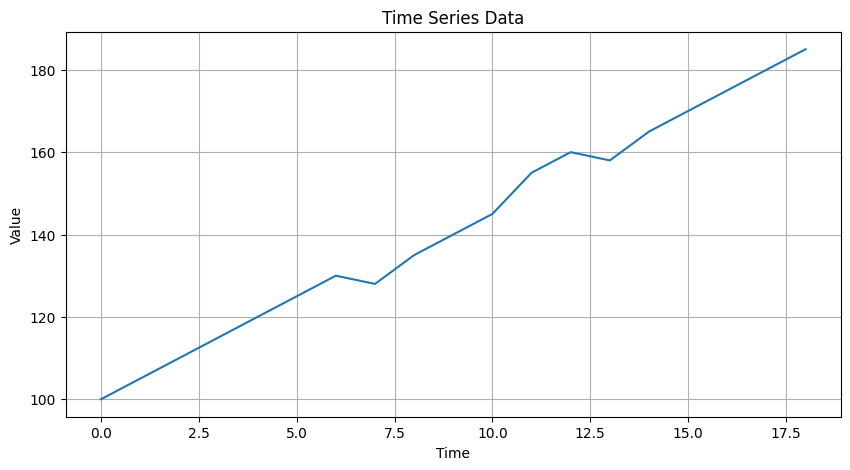

In [7]:
#Visualize data
plt.figure(figsize= (10,5))
plt.plot(df['value'])
plt.title("Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


In [8]:
#Data Normalization
# neural network worl better with scaled data
# convert values btwn 0 and 1
scaler = MinMaxScaler( feature_range=(0,1))
scaled_data= scaler.fit_transform(df)

In [10]:
#Sequence Creation 
def create_dataset(dataset, time_step=3):
    X=[]
    Y=[]
    for i in range(len(dataset)-time_step-1):
        a= dataset[i: (i+time_step),0]
        X.append(a)
        Y.append(dataset[i + time_step,0])

    return np.array(X), np.array(Y)
    

In [11]:
# prepare training data
time_step = 3
X,Y = create_dataset(scaled_data, time_step)
print(X)
print(Y)

[[0.         0.05882353 0.11764706]
 [0.05882353 0.11764706 0.17647059]
 [0.11764706 0.17647059 0.23529412]
 [0.17647059 0.23529412 0.29411765]
 [0.23529412 0.29411765 0.35294118]
 [0.29411765 0.35294118 0.32941176]
 [0.35294118 0.32941176 0.41176471]
 [0.32941176 0.41176471 0.47058824]
 [0.41176471 0.47058824 0.52941176]
 [0.47058824 0.52941176 0.64705882]
 [0.52941176 0.64705882 0.70588235]
 [0.64705882 0.70588235 0.68235294]
 [0.70588235 0.68235294 0.76470588]
 [0.68235294 0.76470588 0.82352941]
 [0.76470588 0.82352941 0.88235294]]
[0.17647059 0.23529412 0.29411765 0.35294118 0.32941176 0.41176471
 0.47058824 0.52941176 0.64705882 0.70588235 0.68235294 0.76470588
 0.82352941 0.88235294 0.94117647]


In [12]:
#LSTM REQUIRE 3D INPUT
X=X.reshape(X.shape[0],X.shape[1],1)
print(X.shape)

(15, 3, 1)


In [15]:
# Build LSTEM Model
model = Sequential()
model.add(LSTM(50, return_sequences=False,input_shape=(time_step,1)))
model.add(Dense(1))



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
LSTM(50)

<LSTM name=lstm_3, built=False>

In [18]:
Dense(1)#output layer predict one value

<Dense name=dense_2, built=False>

In [19]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [20]:
#train the model
history = model.fit(
    X,
    Y,
    epochs= 300,
    verbose=1
    
)


Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3277
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.3146
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3017
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2890
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2765
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2642
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.2520
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.2401
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2283
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2167
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2052
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1940
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1829
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1721
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1614
Epoch 16/300
1/1 ━━━

In [21]:
model.summary()
#shows layers parrameters and output shapes

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [22]:
#prediction
predictions = model.predict(X)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
[[0.18882434]
 [0.23867129]
 [0.2900727 ]
 [0.34300312]
 [0.39743116]
 [0.4363378 ]
 [0.4704602 ]
 [0.5004216 ]
 [0.5692937 ]
 [0.6420195 ]
 [0.7249377 ]
 [0.7979751 ]
 [0.8363619 ]
 [0.8693191 ]
 [0.94651544]]


In [23]:
#convert Back to original values because data is scaled
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(Y.reshape(-1,1))


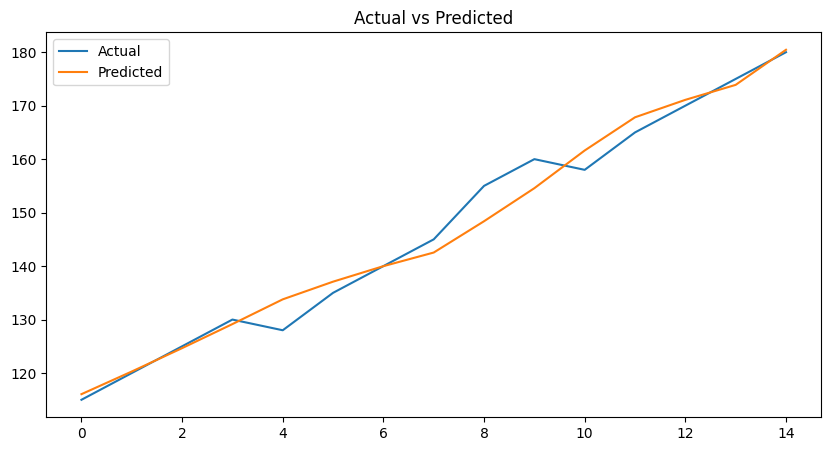

In [24]:
plt.figure (figsize = (10,5))
plt.plot(actual, label= 'Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()